In [4]:
import os

import numpy as np

from pyddeeg.signal_processing.rqa_toolbox import extract_signal_windows

ZEROLAG = "/home/mariopasc/Python/Datasets/EEG/timeseries/processed/zerolag"
STIMULI = "20"
FILES = [os.path.join(ZEROLAG, f) for f in os.listdir(ZEROLAG) if f.endswith(".npz") and STIMULI in f]

BANDWIDTH = 4 # Gamma

print(f"Working with:")
for f in FILES:
    print(f"- {f}")
dd_up = np.load(FILES[1], allow_pickle=True)["data"]
print(f"Loaded {FILES[1]} with shape {dd_up.shape}")

# Work for now with a small set
patient = 0
channel = 11
window_length = 1000 # 1 second

working_data = dd_up[patient, channel, :, BANDWIDTH] 

windows = extract_signal_windows(signal=working_data, window_size=window_length)
print(f"Extracted {windows.shape[0]} windows of size {windows.shape[1]} ms from {working_data.shape} signal")

Working with:
- /home/mariopasc/Python/Datasets/EEG/timeseries/processed/zerolag/DD_DOWN_preprocess_20.npz
- /home/mariopasc/Python/Datasets/EEG/timeseries/processed/zerolag/DD_UP_preprocess_20.npz
- /home/mariopasc/Python/Datasets/EEG/timeseries/processed/zerolag/CT_UP_preprocess_20.npz
- /home/mariopasc/Python/Datasets/EEG/timeseries/processed/zerolag/CT_DOWN_preprocess_20.npz
Loaded /home/mariopasc/Python/Datasets/EEG/timeseries/processed/zerolag/DD_UP_preprocess_20.npz with shape (15, 32, 68000, 5)
Extracted 135 windows of size 1000 ms from (68000,) signal


In [30]:
from pyddeeg.signal_processing.rqa_toolbox.optimization import tune_tau_per_window, tune_m_per_window


n_windows = windows.shape[0]
tau_results = tune_tau_per_window(windows, max_lag=120)
taus = np.array([r["best_tau"] for r in tau_results])

m_results = tune_m_per_window(windows, taus=taus, max_dim=12)

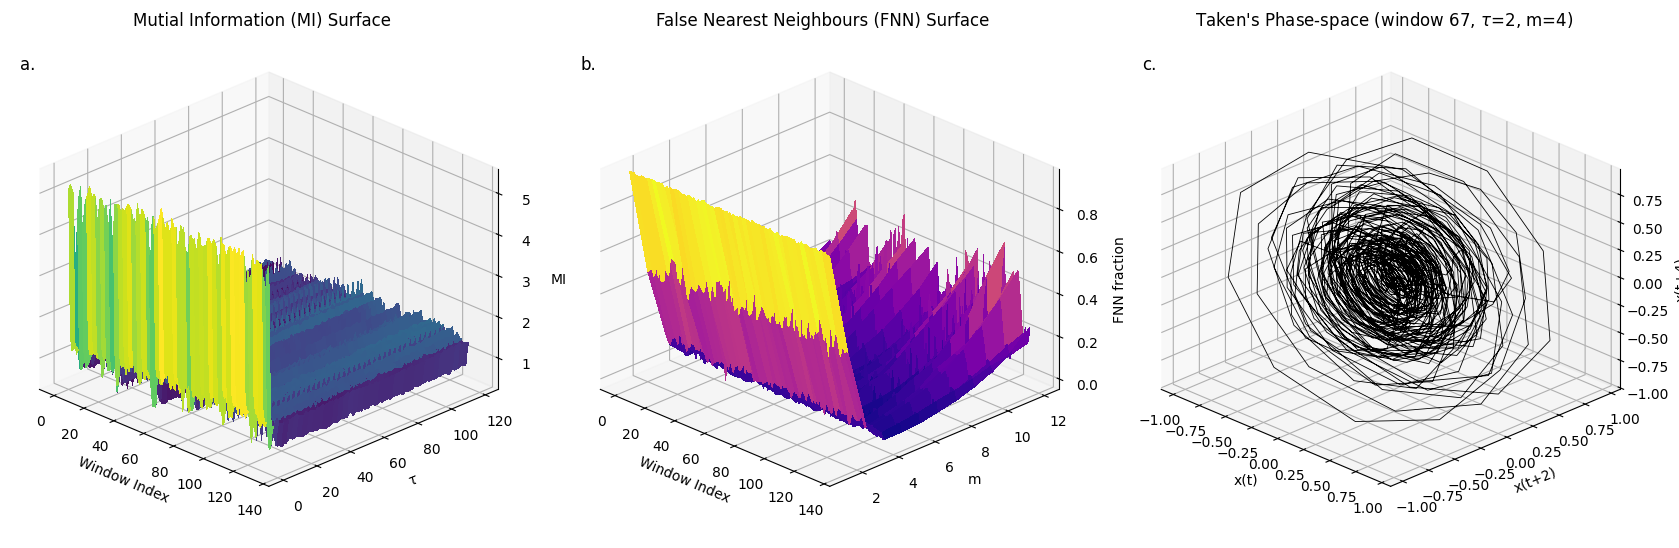

In [107]:
# viz_surfaces.py  –  prettier 3-panel visualisation
# ---------------------------------------------------
from __future__ import annotations
from typing import List, Dict

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from nolitsa import delay as ndelay


def reconstruct(window: np.ndarray, tau: int, m: int) -> np.ndarray:
    """
    Takens embedding (N, m).
    """
    return ndelay.utils.reconstruct(window, dim=m, tau=tau)


def _surface_with_floor(
    ax,
    X: np.ndarray,
    Y: np.ndarray,
    Z: np.ndarray,
    cmap: str,
    zlabel: str,
    mins_x: np.ndarray,
    mins_y: np.ndarray,
    subplot_label: str,
    title: str,
    elev: float,
    azim: float,
):
    """
    Draw a coloured 3D surface, project a lowered heat‐map beneath z=0,
    highlight minima on the surface, and add a subplot letter.
    """
    # 1) main 3D surface
    surf = ax.plot_surface(X, Y, Z, cmap=cmap, linewidth=0, antialiased=False)

    # 2) draw a light z=0 reference plane
    Z0 = np.zeros_like(Z)
    #ax.plot_surface(X, Y, Z0, color='gray', alpha=0.2, linewidth=0)

    # 3) project the heatmap deeper, just below the data's minimum
    data_span = Z.max() - Z.min()
    z_floor = Z.min() - data_span * 0.05
    #ax.contourf(X, Y, Z, zdir='z', offset=z_floor, cmap=cmap, levels=60)

    # 4) highlight minima on the *surface* itself
    z_mins = Z[mins_x, mins_y]
    # ax.scatter(mins_x, mins_y, z_mins, c='red', s=30, marker='o', depthshade=True, label='minimum')

    # 5) aesthetics & view
    ax.set_zlim(z_floor, Z.max())
    ax.set(xlabel='Window Index', zlabel=zlabel, title=title)
    ax.view_init(elev=elev, azim=azim)

    # 6) subplot letter in top-left (axes coordinates)
    ax.text2D(0.02, 0.93, subplot_label,
              transform=ax.transAxes,
              fontsize=12, fontweight='normal')

    # 7) colourbar for this surface
    mappable = plt.cm.ScalarMappable(cmap=cmap)
    mappable.set_array(Z)


def _set_axes_equal(ax):
    """
    Make 3D axes have equal scale so that units are represented uniformly.
    """
    limits = np.array([ax.get_xlim3d(),
                       ax.get_ylim3d(),
                       ax.get_zlim3d()])
    spans = limits[:, 1] - limits[:, 0]
    center = np.mean(limits, axis=1)
    radius = 0.5 * max(spans)
    new_limits = np.array([center - radius, center + radius]).T
    ax.set_xlim3d(new_limits[0])
    ax.set_ylim3d(new_limits[1])
    ax.set_zlim3d(new_limits[2])


def plot_tau_fnn_attractor(
    tau_results: List[Dict],
    m_results: List[Dict],
    windows: np.ndarray,
    win_to_show: int | None = None,
    *,
    elev: int = 25,
    azim: int = -55,
) -> None:
    """
    3-panel figure: MI surface, FNN surface, 3-D attractor for one window.
    """
    # pick the middle window by default
    n_win = len(tau_results)
    if win_to_show is None:
        win_to_show = n_win // 2

    # stack results into matrices
    mi_mat = np.stack([r["mi"] for r in tau_results])
    fnn_mat = np.stack([r["f3"] for r in m_results])

    W_tau, TAU = np.meshgrid(np.arange(n_win),
                             tau_results[0]["taus"],
                             indexing="ij")
    W_m, M = np.meshgrid(np.arange(n_win),
                         m_results[0]["dims"],
                         indexing="ij")

    # compute one trajectory
    tau_star = tau_results[win_to_show]["best_tau"]
    m_star   = m_results[win_to_show]["best_m"]
    attract  = reconstruct(windows[win_to_show], tau_star, m_star)

    # prepare figure
    fig = plt.figure(figsize=(18, 6))
    fig.patch.set_facecolor('white')  # white around the panels

    # a) MI surface
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    mins_tau = np.array([r["best_tau"] for r in tau_results])
    _surface_with_floor(
        ax1, W_tau, TAU, mi_mat, cmap='viridis', zlabel='MI',
        mins_x=np.arange(n_win), mins_y=mins_tau - 1,
        subplot_label='a.', title='Mutial Information (MI) Surface',
        elev=elev, azim=azim
    )
    ax1.set_ylabel(r'$\tau$')

    # b) FNN surface
    ax2 = fig.add_subplot(1, 3, 2, projection='3d')
    mins_m = np.array([r["best_m"] for r in m_results])
    _surface_with_floor(
        ax2, W_m, M, fnn_mat, cmap='plasma', zlabel='FNN fraction',
        mins_x=np.arange(n_win), mins_y=mins_m - 1,
        subplot_label='b.', title='False Nearest Neighbours (FNN) Surface',
        elev=elev, azim=azim
    )
    ax2.set_ylabel('m')

    # c) phase-space attractor
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    ax3.plot(attract[:, 0], attract[:, 1], attract[:, 2],
             lw=0.6, color='black')
    ax3.set(title=(f"Taken's Phase-space (window {win_to_show}, "
                   f"$\\tau$={tau_star}, m={m_star})"),
            xlabel="x(t)",
            ylabel=rf"x(t+{tau_star})",
            zlabel=rf"x(t+{2*tau_star})")
    ax3.view_init(elev=elev, azim=azim)
    ax3.text2D(0.02, 0.93, 'c.',
               transform=ax3.transAxes,
               fontsize=12, fontweight='normal')

    # orthographic + equal aspect + zoom
    for ax in (ax1, ax2, ax3):
        ax.set_proj_type('ortho')
        ax.dist = 9

    # spread the panels out
    fig.subplots_adjust(left=0.05, right=0.97,
                        top=0.92, bottom=0.08,
                        wspace=0.05)
    # save with extra white padding so nothing is clipped
    plt.savefig(
        "tau_fnn_attractor.png",
        dpi=300,
        facecolor='white',
        bbox_inches='tight',
        pad_inches=0.2,
    )

    plt.show()

plot_tau_fnn_attractor(tau_results, m_results, windows, elev=25, azim=-45)


Takens shape (tau, m, eps): (15, 3, 135)
Window centers size (ms): (135,)
Stride (ms): 500


/tmp/ipykernel_54327/3828939277.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([tau_series, m_series, eps_series], labels=['tau', 'm', 'eps'])


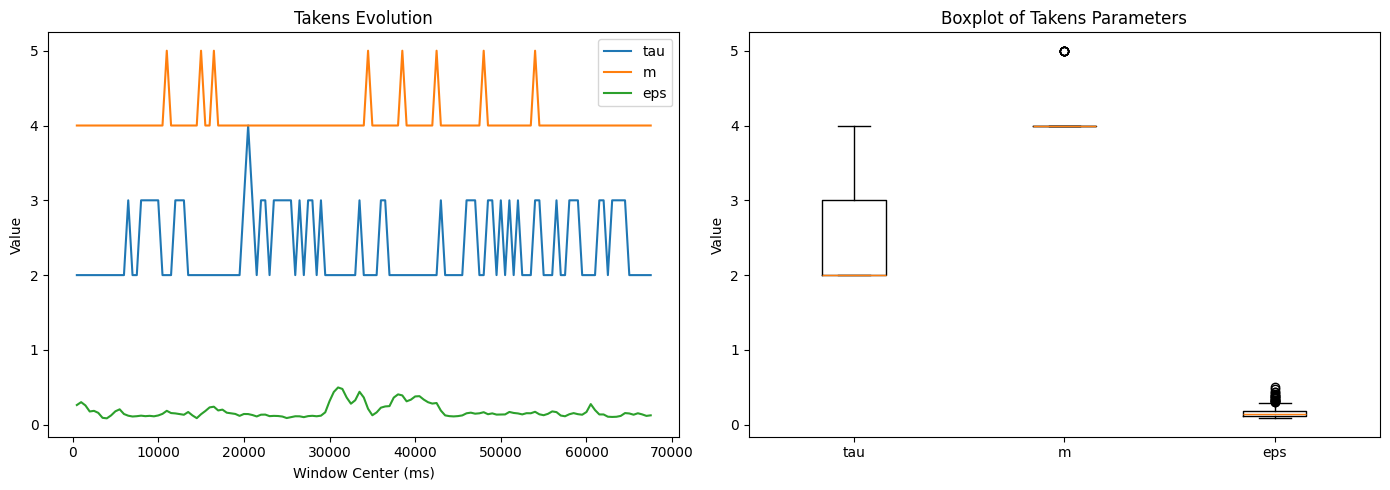

In [27]:
import os

window = "w1000"

path = "/home/mariopasc/Python/Datasets/EEG/timeseries/processed/rqa_windows/rqa_ch_T7_20250427_183844/DD_UP"
files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(".npz")]

metrics = np.load(files[0], allow_pickle=True)
takens = np.load(files[1], allow_pickle=True)

window_centers = metrics[f"{window}_centers"]
stride = metrics[f"{window}_stride"]
takens = takens[f"{window}_takens"]

print(f"Takens shape (tau, m, eps): {takens.shape}")
print(f"Window centers size (ms): {window_centers.shape}")
print(f"Stride (ms): {stride}")

import matplotlib.pyplot as plt
import numpy as np

# Assuming 'takens' shape is (tau, m, eps) == (15, 3, 135)
# and window_centers shape is (135,)

# For each window, extract the optimal tau, m, eps (assuming along axis 0, 1, 2)
# If you have arrays of best_tau, best_m, best_eps per window, use those.
# Otherwise, for demonstration, let's assume:
# - tau: takens[0, 0, :] (or your actual best_tau per window)
# - m: takens[0, 1, :]
# - eps: takens[0, 2, :]

# If you have best indices, use them instead!
tau_series = takens[0, 0, :]  # Replace with your best_tau per window if available
m_series = takens[0, 1, :]
eps_series = takens[0, 2, :]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Evolution as 3 data series
axes[0].plot(window_centers, tau_series, label='tau')
axes[0].plot(window_centers, m_series, label='m')
axes[0].plot(window_centers, eps_series, label='eps')
axes[0].set_xlabel('Window Center (ms)')
axes[0].set_ylabel('Value')
axes[0].set_title('Takens Evolution')
axes[0].legend()

# 2. Boxplot for each
axes[1].boxplot([tau_series, m_series, eps_series], labels=['tau', 'm', 'eps'])
axes[1].set_title('Boxplot of Takens Parameters')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()